In [1]:
#import packages
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk
import cartopy.crs as ccrs
import time
import matplotlib as mpl
from scipy.stats import linregress
# import dask
import matplotlib.ticker as mticker
import string
letters=[]
for letter in string.ascii_lowercase[0:24]:
    letters.append(letter+". ")
from functions import *
from scipy.stats import t
import os

In [2]:
#functions
def cutcanada(dat):

    datout=dat.sel(latitude=slice(40,80), longitude=slice(-142.5,-55))

    return datout

def lineout(dat):
    temp_seas=dat.groupby('time.season')

    # year= np.arange(1950,2025)
    temp_dy_seas=xr.full_like(dat.groupby('time.year').mean().expand_dims(season=titles).copy(),np.nan)

    trseas_mn=[]
    pvseas_mn=[]
    for i,ss in enumerate(titles):
        tempdy=temp_seas[ss].groupby('time.year').mean()
        temp_dy_seas[i,]=tempdy
    #temp_dy_seas_pc=temp_dy_seas.to_dataset(name='tas')
    return temp_dy_seas
def seassum(dat):
    count_days=[90,92,92,91]
    ht_seas=dat.copy()
    for i in range(4):
        ht_seas[i,]=count_days[i]*dat[i,]
    return ht_seas

#prepare mam only
def seas(dat, season):
    dat1=dat.sel(season=season)#-dat.sel(season='SON')
    dat2=dat1.stack(z={'latitude','longitude'})

    lat_radians = np.deg2rad(dat2.unstack().latitude)
    weights = np.cos(lat_radians)

    dat_weighted=dat2.unstack().weighted(weights).mean(("longitude", "latitude"))
    return dat_weighted 

def corsp(dat1,dat2):
    if not np.isnan(dat1).all() and not np.isnan(dat1).all():
        try:
            res = stats.pearsonr(dat1,dat2)
            slope=res[0]
            pval=res[1]
        except:
            slope=np.nan
            pval=np.nan
#         slope_td[i,j]=trend[-2]
#         pval_td[i,j]=trend[2]
    else:
        slope=np.nan
        pval=np.nan
    return slope, pval


In [5]:
#read cmip, era, bk temp dat
temp_mult=xr.open_dataset('../timing/cmip6_tas_day_hist-ssp_25models_1950-2021_regridcon.nc').sel(time=slice('1950-01-01','2012-12'))

#read ERA5 and berkley

tmn=xr.open_dataset('../timing/era5/era5_tmean_daily_1950_2024_regridcon.nc')
tmn1=tmn.sortby(tmn.time).rename({'lat':'latitude','lon':'longitude'})
#heat79=cuttimestart(heat1,1979)
tmn_midl=cutmidlat(rotlon_180(tmn1))

tmn_midlat=landmask(tmn_midl)
tmn_midlat21=tmn_midlat.sel(time=slice('1950-01-01','2012-12-31'))
tmn_noleap21=tmn_midlat21.convert_calendar('noleap')

tmn_pc=xr.open_dataset('pcic/tas_day_PCIC_Blended_Observations_v1_1950-2012_regridcon.nc')
tmn_pc1=tmn_pc.sortby(tmn_pc.time).rename({'lat':'latitude','lon':'longitude'})
#heat79=cuttimestart(heat1,1979)
tmnpc_midl=cutmidlat(rotlon_180(tmn_pc1))

tmnpc_midlat=landmask(tmnpc_midl)
tmnpc_noleap=tmnpc_midlat.convert_calendar('noleap')



In [6]:
#seasmean temp
tmphist_lnd=landmask(temp_mult).groupby('time.season').mean()

trseas_tmp_era=landmask(tmn_midl).groupby('time.season').mean()

tmphist_lnd=tmphist_lnd.tas
trseas_tmp_era=trseas_tmp_era.t2m

In [12]:
# #change in hot spells data (CMIP6)
titles=tmn_midl.time.dt.season.values
models1=['ACCESS-CM2','AWI-CM-1-1-MR','BCC-CSM2-MR', 'CanESM5','CESM2','CMCC-ESM2','CNRM-ESM2-1','EC-Earth3-CC','GFDL-ESM4','IITM-ESM','INM-CM5-0','KIOST-ESM','MIROC6','MPI-ESM1-2-LR','MRI-ESM2-0','NESM3','NorESM2-MM','TaiESM1']# temp_datcut={}
models22=['CESM2-WACCM', 'CMCC-CM2-SR5', 'CNRM-CM6-1','INM-CM4-8','IPSL-CM6A-LR', 'MIROC-ES2L','CNRM-CM6-1-HR']
models=np.array(models1+models22)
htfut_cmip2=[]
for i,mod in enumerate(models):
    trseas_heatfut2=xr.open_dataset('../timing/cmip6/heat/'+mod+'_tasmean_heat_days_1950-2100_fixed.nc').heatdays
    htfut_midl2=cutmidlat(trseas_heatfut2)
    #htfut_lnd2=landmask(htfut_midl2)
    
    htfut_lnd2=landmask(htfut_midl2)#.sel(time=slice('1950-01-01','2099-12-31'))
    heat_midlat=htfut_lnd2.drop_duplicates(dim="time").sel(time=slice('1950-01-01','2099-12-31'))

    if i==9:
        heat_midlat2=xr.concat([heat_midlat,htfut_cmip2[0].sel(time='2026-01-01')], dim='time')
        heat_midlat2[-1,]=heat_midlat.sel(time='2026-01-02').isel(time=0).values
        heat_midlat=heat_midlat2.sortby(heat_midlat2.time) 
    if i>0:
        heat_midlat['time']= htfut_cmip2[0].time.values
    htfut_cmip2.append(heat_midlat)



KeyboardInterrupt



In [ ]:
#concatenate and compute changes
ht_conc=xr.concat(htfut_cmip2,dim='models').assign_coords(models=models)
htfut_lndclim = ht_conc.groupby("time.year").map(
        lambda x: x.groupby("time.season").sum("time")
    )
change_heatfut=htfut_lndclim.sel(year=slice(2070,2100)).mean(dim='year') - htfut_lndclim.sel(year=slice(1950,1980)).mean(dim='year') 
change_heathist=htfut_lndclim.sel(year=slice(1984,2014)).mean(dim='year') - htfut_lndclim.sel(year=slice(1950,1980)).mean(dim='year') 


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB o

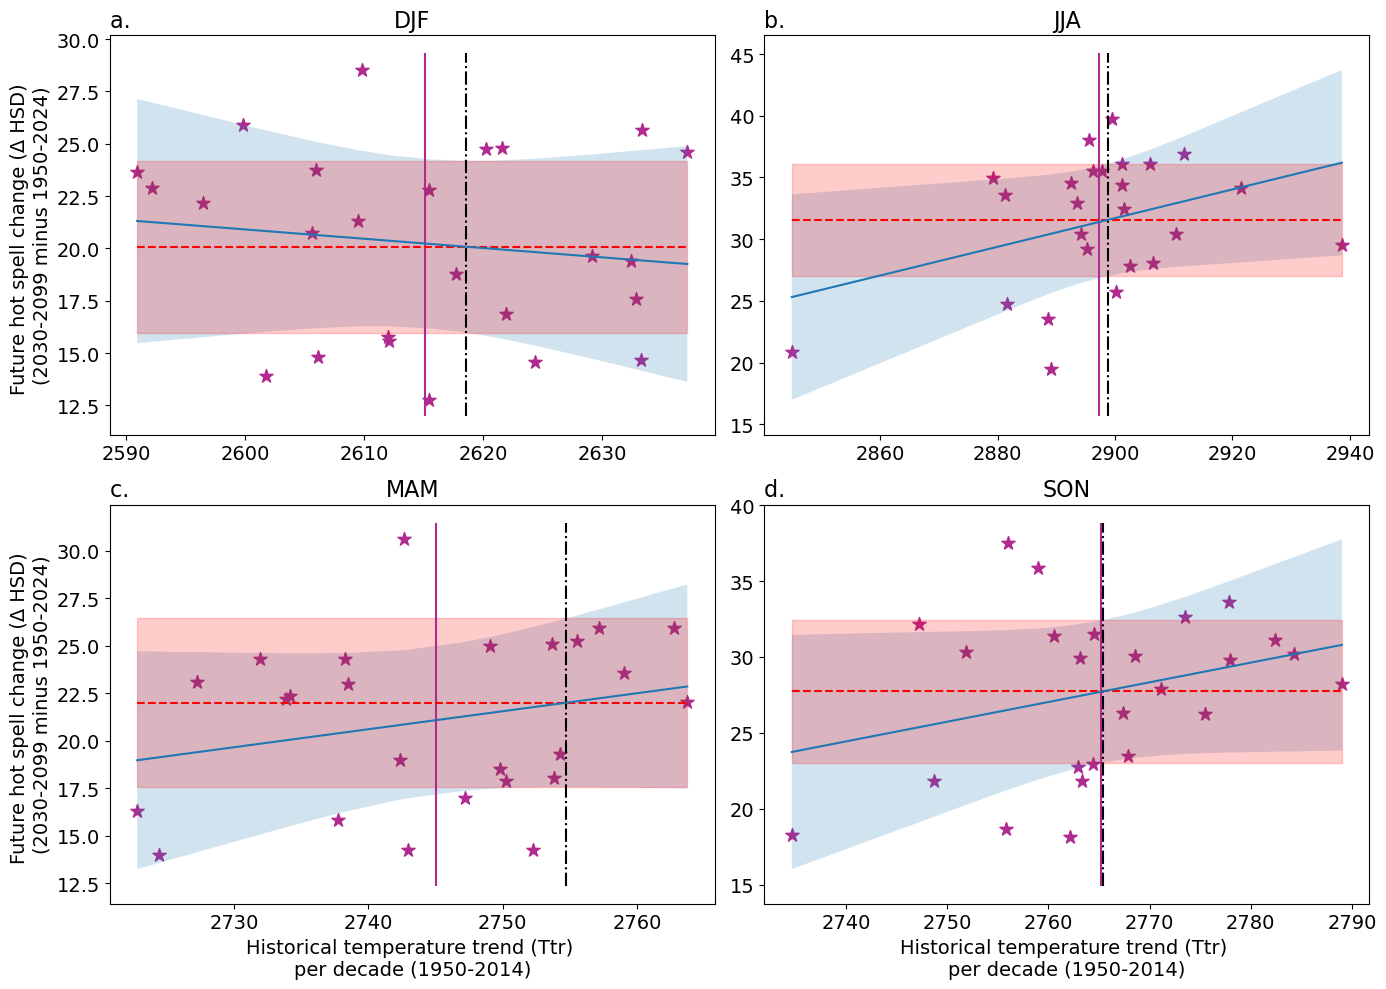

In [9]:
#plot correlation on average
fig=plt.figure(figsize=(14,10))
cmap = plt.get_cmap('plasma')
cmap2 = plt.get_cmap('YlGn')

for i,season in enumerate(change_heatfut.season.values):
    
    ax=fig.add_subplot(2,2,i+1)
    xtmp_weighted=seas(tmphist_lnd,season)
    y_weighted=seas(change_heatfut,season)
    
    xtmpera_weighted=seas(trseas_tmp_era,season)
    #xtmpbk_weighted=seas(trseas_tmp_bk,season)
    ax.scatter(10*xtmp_weighted,y_weighted,marker='*', s=100,c=cmap(0.4),label='CMIP6 (μ)')
    
    #ax.vlines(10*xtmpbk_weighted,0,10*y_weighted.max(),color=cmap2(0.75),linestyle='--',label='Berkeley (μ)')
    
    xtmp_weighted2=xtmp_weighted.sortby(xtmp_weighted)
    y_weighted2=y_weighted.sortby(xtmp_weighted)
    
    x=10*xtmp_weighted2.values
    y=y_weighted2.values
    
    xob=10*xtmpera_weighted
    n=len(x)
    a, b = np.polyfit(x, y, deg=1)
    y_est = a * x + b
    
    
    
    y_mmm=y_est.mean()
    x_mmm=x.mean()
    
    y_ob=a*(xob - x_mmm)+ y_mmm


    # Calculate the standard error of the estimate (manual formula)

    SE = np.sqrt((np.array(y)-y_est).var() * np.sqrt(1/len(x) + (x - x.mean())**2 / np.sum((x - x.mean())**2)))

    tc = t.ppf(0.975, n-2)
    CIupper=y_est+(tc*SE)
    CIlower=y_est-(tc*SE)
    
    SE_o=  np.sqrt((np.array(y)-y_est).var() * np.sqrt(1/len(x) + (xob - x.mean())**2 / np.sum((x - x.mean())**2)))
    CIupperob=y_ob+(tc*SE_o)
    CIlowerob=y_ob-(tc*SE_o)
    
    
    CIupper=np.append(CIupper,CIupperob)
    CIlower=np.append(CIlower,CIlowerob)
    y_est=np.append(y_est,y_ob)
    x=np.append(x,xob)
    
    indices = np.argsort(x)


    x = x[indices]
    y_est = y_est[indices]
    CIupper = CIupper[indices]
    CIlower = CIlower[indices]
    
    ax.fill_between(x, CIlower, CIupper, alpha=0.2)
    
    
    ax.fill_between(x, CIlowerob, CIupperob,color= 'red', alpha=0.2)
    
    ax.plot(x, y_est, '-', label='Linear Fit')
    
    ymin, ymax = plt.ylim()
    ax.vlines(10*xtmp_weighted.mean(),ymin,ymax,color=cmap(0.4),label='CMIP6 mmm (μ)')
    ax.vlines(10*xtmpera_weighted,ymin,ymax,color='k', linestyle='-.',label='ERA5 (μ)')
    
    ax.hlines(y_ob,x.min(),x.max(),color='red',linestyle='--',label='CMIP adjmean')
    
    #ax.fill_between(x, y_est - y_err, y_est + y_err, alpha=0.2, label='Uncertainty Band')
    ax.set_title(letters[i], loc='left', fontsize=16)
    ax.set_title(season, fontsize=16)
    ax.set_ylabel('Future hot spell change (\u0394 HSD) \n(2030-2099 minus 1950-2024)', fontsize=14)
    ax.set_xlabel('Historical temperature trend (Ttr) \nper decade (1950-2014)', fontsize=14)
    
    if i%2>0:
        ax.set_ylabel('')
    if i<2:
        ax.set_xlabel('')


    plt.yticks(fontsize=14)
    plt.xticks(fontsize=14)
handles=[]
labels=[]
h, l = ax.get_legend_handles_labels()
handles.extend(h)
labels.extend(l)
#fig.legend(handles, labels, loc='lower right', fontsize=14, bbox_to_anchor=(0.65, 0.1)) 
plt.tight_layout()
plt.savefig('Plots/ECs_tmean_clim_version.png')


In [96]:
#Compute correlation values (against Future 30year)
print ('Future 30year clims')
for i,season in enumerate(change_heatfut.season.values):
    xtmp_weighted=seas(tmphist_lnd,season)
    y_weighted=seas(change_heatfut,season)
    res = stats.pearsonr(xtmp_weighted,y_weighted)
    print(season+' Corr:',res)


Future 30year clims
DJF Corr: PearsonRResult(statistic=-0.13388576522472123, pvalue=0.5234481265598286)
JJA Corr: PearsonRResult(statistic=0.3405674985214703, pvalue=0.09573614697617841)
MAM Corr: PearsonRResult(statistic=0.2546893999050012, pvalue=0.21920799407769626)
SON Corr: PearsonRResult(statistic=0.281387213504461, pvalue=0.17300018663033925)


In [11]:
#Compute correlation values (against historical 30year)
print ('Historical 30year clims')
for i,season in enumerate(change_heathist.season.values):
    xtmp_weighted=seas(tmphist_lnd,season)
    y_weighted=seas(change_heathist,season)
    res = stats.pearsonr(xtmp_weighted,y_weighted)
    print(season+' Corr:',res)


Historical 30year clims
DJF Corr: PearsonRResult(statistic=0.0041699006907013995, pvalue=0.9842171963584657)
JJA Corr: PearsonRResult(statistic=-0.007832413424957278, pvalue=0.9703593835400641)
MAM Corr: PearsonRResult(statistic=0.039526398736610575, pvalue=0.8512005240672486)
SON Corr: PearsonRResult(statistic=0.2624094936653388, pvalue=0.205075552014225)


## Fluxes

In [12]:
#read rsus
models=['ACCESS-CM2', 'AWI-CM-1-1-MR', 'BCC-CSM2-MR','CAMS-CSM1-0', 'CanESM5-CanOE', 'CESM2', 'CMCC-ESM2', 'CMCC-CM2-SR5', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'E3SM-1-1', 'FGOALS-g3', 'IITM-ESM',  'MIROC6', 'MPI-ESM1-2-LR', 'NESM3', 'NorESM2-MM']
to_con1=[]
to_con2=[]
to_con_rsus=[]
for i,mod in enumerate(models):
    dat=xr.open_dataset('cmip6/rsus_Amon_'+mod+'_historical_regridcon.nc')#.rename({'lat':'latitude','lon':'longitude'})
    dat1=dat.convert_calendar('noleap').rename({'lon':'longitude','lat':'latitude'})
    temp_dat=rotlon_180(dat1)
    tmp1=temp_dat.sortby(temp_dat.time)
    tmp_midl=cutmidlat(tmp1)
    tmp_midlat1=landmask(tmp_midl)
    tmp_midlat1=tmp_midlat1.drop_duplicates(dim="time")
    if i>0:
        tmp_midlat1['time']=to_con_rsus[0].time.values
  # temp_datcut[mod]=temp_dat#.sel(time=(slice('1950-01-01','2024-12-31')))

    
    to_con_rsus.append(tmp_midlat1)

In [13]:
#read rsds
models=['ACCESS-CM2', 'AWI-CM-1-1-MR', 'BCC-CSM2-MR','CAMS-CSM1-0', 'CanESM5-CanOE', 'CESM2', 'CMCC-ESM2', 'CMCC-CM2-SR5', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'E3SM-1-1', 'FGOALS-g3', 'IITM-ESM',  'MIROC6', 'MPI-ESM1-2-LR', 'NESM3', 'NorESM2-MM']
to_con1=[]
to_con2=[]
to_con_rsds=[]
for i,mod in enumerate(models):
    dat=xr.open_dataset('cmip6/rsds_Amon_'+mod+'_historical_regridcon.nc')#.rename({'lat':'latitude','lon':'longitude'})
    dat1=dat.convert_calendar('noleap').rename({'lon':'longitude','lat':'latitude'})
    temp_dat=rotlon_180(dat1)
    tmp1=temp_dat.sortby(temp_dat.time)
    tmp_midl=cutmidlat(tmp1)
    tmp_midlat1=landmask(tmp_midl)
    tmp_midlat1=tmp_midlat1.drop_duplicates(dim="time")
    if i>0:
        tmp_midlat1['time']=to_con_rsds[0].time.values
    
    to_con_rsds.append(tmp_midlat1)

In [14]:
#read hfls
models1=['ACCESS-CM2','AWI-CM-1-1-MR','BCC-CSM2-MR','CESM2','CMCC-ESM2','CNRM-ESM2-1','EC-Earth3-CC','GFDL-ESM4','IITM-ESM','INM-CM5-0','MIROC6','MPI-ESM1-2-LR','MRI-ESM2-0','NESM3','NorESM2-MM','TaiESM1']# temp_datcut={}
models22=['CESM2-WACCM','CNRM-CM6-1','INM-CM4-8','IPSL-CM6A-LR', 'MIROC-ES2L','CNRM-CM6-1-HR']
models_hfls=np.array(models1+models22)
to_con1=[]
to_con2=[]
to_con_hfls=[]
for i,mod in enumerate(models_hfls):
    dat=xr.open_dataset('cmip6/hfls_Amon_'+mod+'_historical_regridcon.nc')#.rename({'lat':'latitude','lon':'longitude'})

    dat1=dat.convert_calendar('noleap').rename({'lon':'longitude','lat':'latitude'})
    temp_dat=rotlon_180(dat1)
    tmp1=temp_dat.sortby(temp_dat.time)
    tmp_midl=cutmidlat(tmp1)
    tmp_midlat1=landmask(tmp_midl)
    tmp_midlat1=tmp_midlat1.drop_duplicates(dim="time")
    if i>0:
        tmp_midlat1['time']=to_con_hfls[0].time.values
    to_con_hfls.append(tmp_midlat1)
#     try:
#         to_con_hfss.append(tmp_midlat1.drop_vars('depth'))
#     except:
#         to_con_hfss.append(tmp_midlat1)

In [15]:
#read hfss
models1=['ACCESS-CM2','AWI-CM-1-1-MR', 'CanESM5','CESM2','CMCC-ESM2','CNRM-ESM2-1','GFDL-ESM4','IITM-ESM','INM-CM5-0','KIOST-ESM','MIROC6','MPI-ESM1-2-LR','MRI-ESM2-0','NESM3','NorESM2-MM','TaiESM1']# temp_datcut={}
models22=['CESM2-WACCM', 'CMCC-CM2-SR5', 'CNRM-CM6-1','INM-CM4-8','IPSL-CM6A-LR', 'MIROC-ES2L','CNRM-CM6-1-HR']
models_hfss=np.array(models1+models22)
to_con1=[]
to_con2=[]
to_con_hfss=[]
for i,mod in enumerate(models_hfss):
    dat=xr.open_dataset('cmip6/hfss_Amon_'+mod+'_historical_regridcon.nc')#.rename({'lat':'latitude','lon':'longitude'})
    dat1=dat.convert_calendar('noleap').rename({'lon':'longitude','lat':'latitude'})
    temp_dat=rotlon_180(dat1)
    tmp1=temp_dat.sortby(temp_dat.time)
    tmp_midl=cutmidlat(tmp1)
    tmp_midlat1=landmask(tmp_midl)
    tmp_midlat1=tmp_midlat1.drop_duplicates(dim="time")
    if i>0:
        tmp_midlat1['time']=to_con_hfss[0].time.values
    to_con_hfss.append(tmp_midlat1)

In [16]:
#concatenate
rsus_cmip=xr.concat(to_con_rsus, dim='model')
rsds_cmip=xr.concat(to_con_rsds, dim='model')
hfls_cmip=xr.concat(to_con_hfls, dim='model')
hfss_cmip=xr.concat(to_con_hfss, dim='model')

In [18]:
#model names
models_alb=np.array(['ACCESS-CM2', 'AWI-CM-1-1-MR', 'BCC-CSM2-MR','CAMS-CSM1-0', 'CanESM5-CanOE', 'CESM2', 'CMCC-ESM2', 'CMCC-CM2-SR5', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'E3SM-1-1', 'FGOALS-g3', 'IITM-ESM',  'MIROC6', 'MPI-ESM1-2-LR', 'NESM3', 'NorESM2-MM'])
models_albsh=models_alb[np.isin(models_alb,models)]

models1=['ACCESS-CM2','AWI-CM-1-1-MR','BCC-CSM2-MR','CESM2','CMCC-ESM2','CNRM-ESM2-1','EC-Earth3-CC','GFDL-ESM4','IITM-ESM','INM-CM5-0','MIROC6','MPI-ESM1-2-LR','MRI-ESM2-0','NESM3','NorESM2-MM','TaiESM1']# temp_datcut={}
models22=['CESM2-WACCM','CNRM-CM6-1','INM-CM4-8','IPSL-CM6A-LR', 'MIROC-ES2L','CNRM-CM6-1-HR']
models_hfls=np.array(models1+models22)
models_hflssh=models_hfls[np.isin(models_hfls,models)]

models1=['ACCESS-CM2','AWI-CM-1-1-MR', 'CanESM5','CESM2','CMCC-ESM2','CNRM-ESM2-1','GFDL-ESM4','IITM-ESM','INM-CM5-0','KIOST-ESM','MIROC6','MPI-ESM1-2-LR','MRI-ESM2-0','NESM3','NorESM2-MM','TaiESM1']# temp_datcut={}
models22=['CESM2-WACCM', 'CMCC-CM2-SR5', 'CNRM-CM6-1','INM-CM4-8','IPSL-CM6A-LR', 'MIROC-ES2L','CNRM-CM6-1-HR']
models_hfss=np.array(models1+models22)
models_hfsssh=models_hfss[np.isin(models_hfss,models)]

mnames1=[models_albsh,models_albsh,models_hflssh,models_hfsssh]
mnames2=[models_alb,models_alb,models_hfls,models_hfss]


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB o

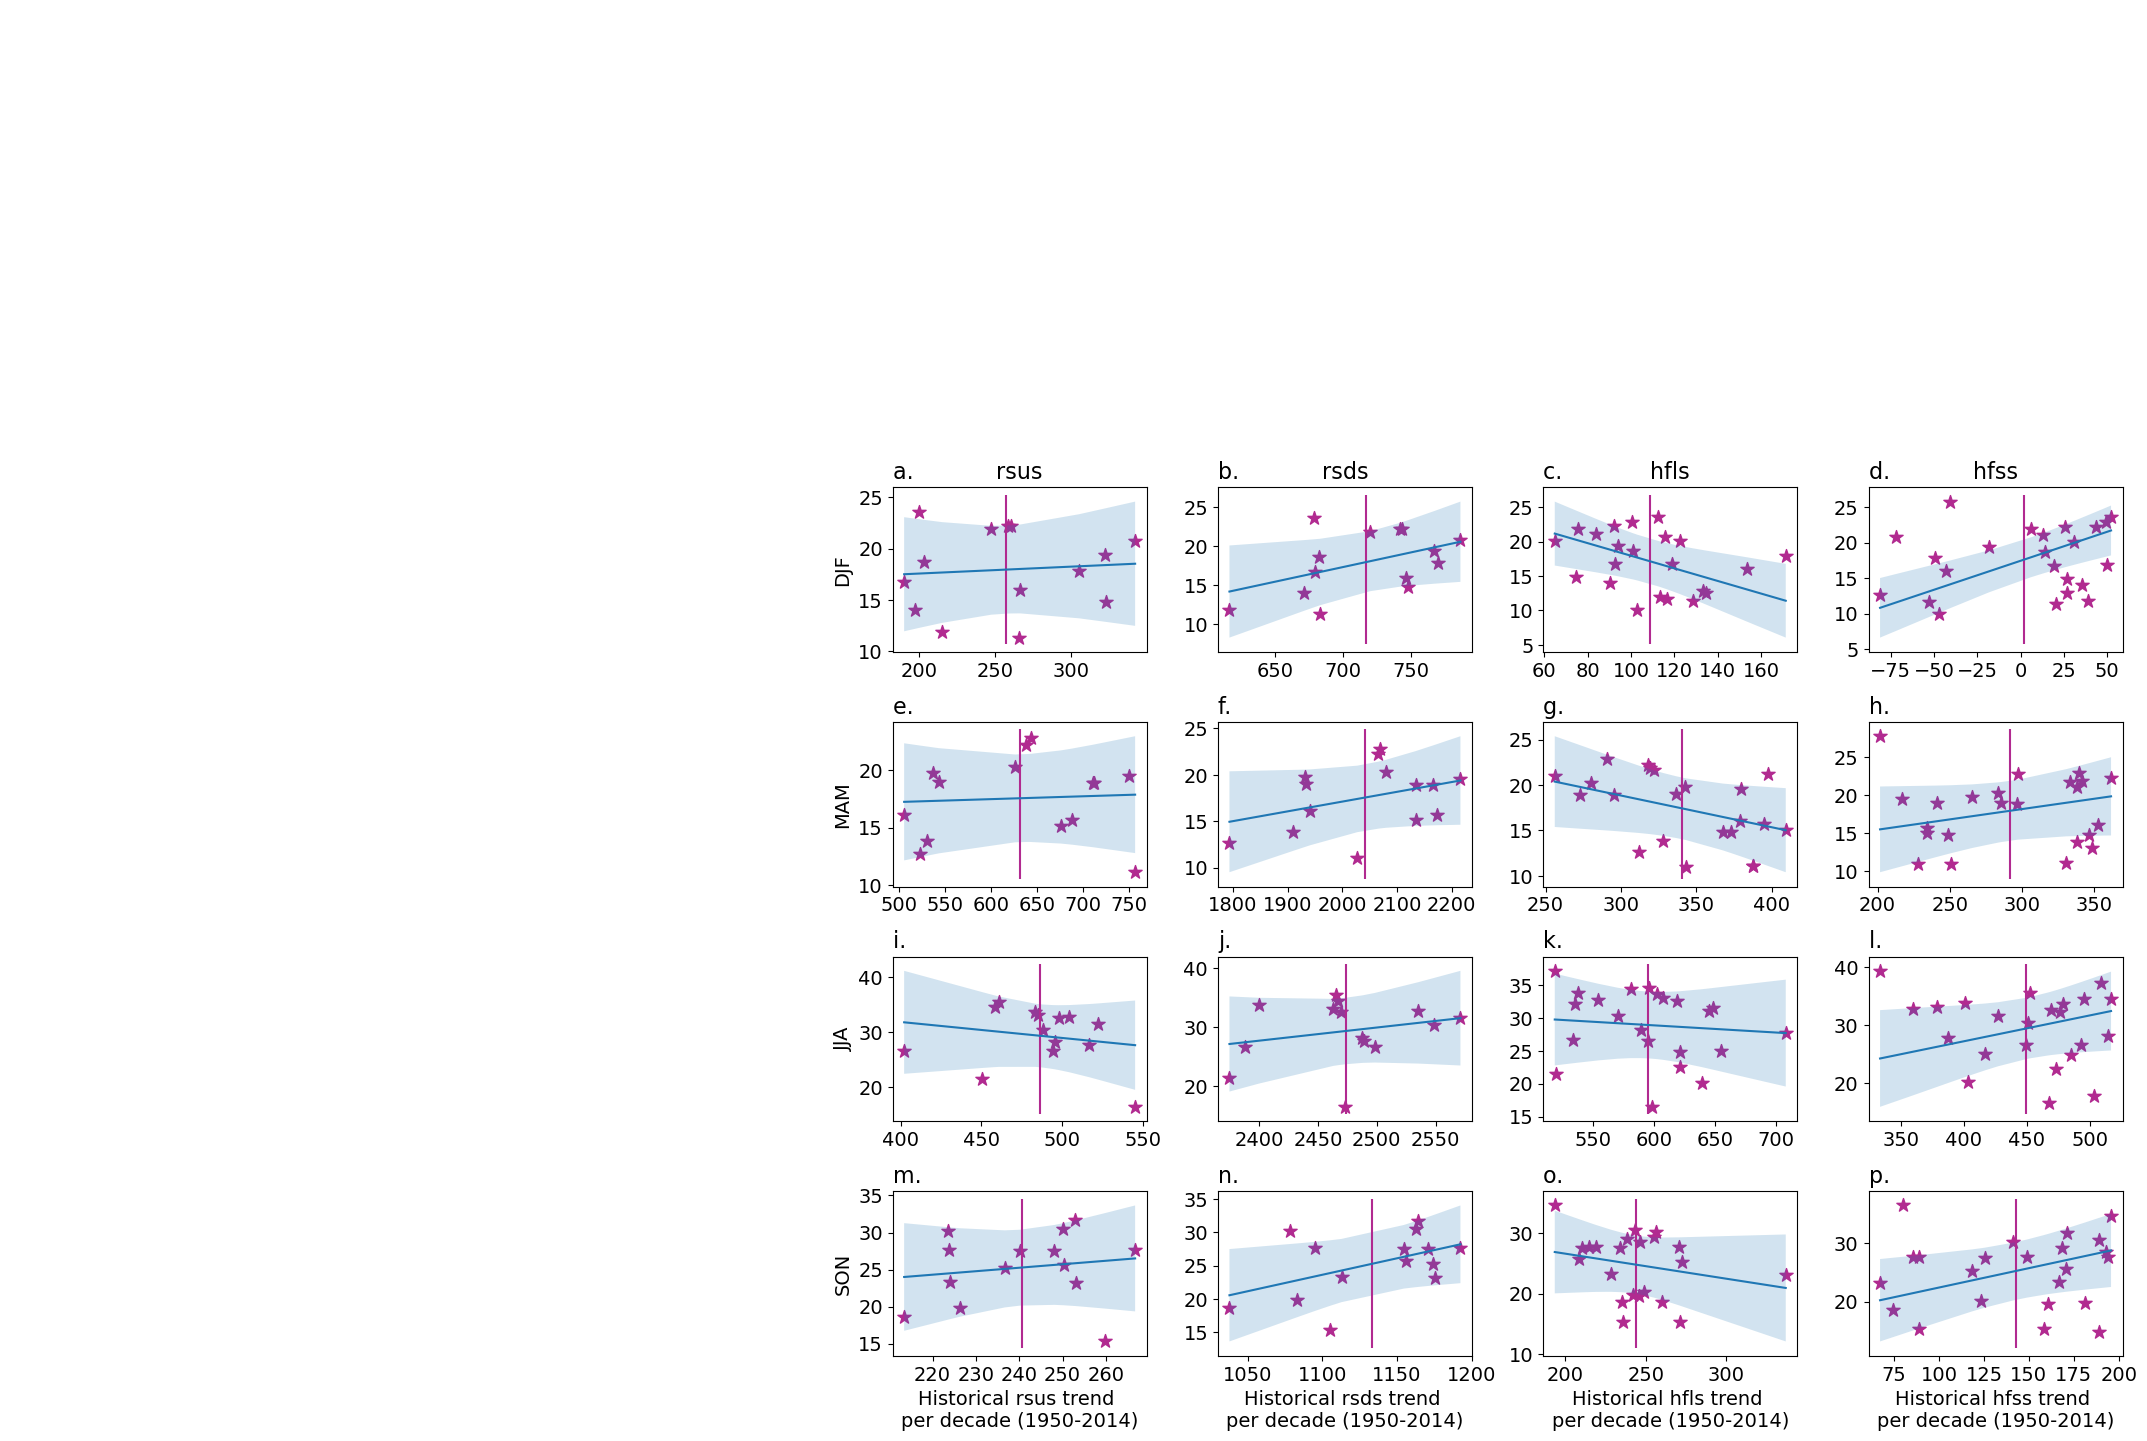

In [59]:
#plot correlation on average
fig=plt.figure(figsize=(14,10))
cmap = plt.get_cmap('plasma')
cmap2 = plt.get_cmap('YlGn')

fig.text(-3.85, 2.5, 'Future hot spell change (\u0394 HSD)(2030-2099 minus 1950-2024)', fontsize=14, rotation='vertical', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)

order=np.array([0,2,1,3])
ss=change_heatfut.season.values
ss2=np.array([ss[0],ss[2],ss[1],ss[3]])
for i,season in enumerate(ss2):
    for j,d in enumerate(dflx):
        num=(4*(i+1)+(j+1) -4)
        ax=fig.add_subplot(4,4,num)
        x_weighted=seas(d,season).sel(models=mnames1[j])
        y_weighted=seas(change_heatfut,season).sel(models=mnames1[j]).sortby(x_weighted.models)

#         xera_weighted=seas(trseas_tmp_era,season)
#         xbk_weighted=seas(trseas_tmp_bk,season)
        ax.scatter(10*x_weighted,y_weighted,marker='*', s=100,c=cmap(0.4),label='CMIP6 (μ)')

        #ax.vlines(10*xbk_weighted,0,10*y_weighted.max(),color=cmap2(0.75),linestyle='--',label='Berkeley (μ)')

        x_weighted2=x_weighted.sortby(x_weighted)
        y_weighted2=y_weighted.sortby(x_weighted)

        x=10*x_weighted2.values
        y=y_weighted2.values

        #xob=10*xera_weighted
        n=len(x)
        a, b = np.polyfit(x, y, deg=1)
        y_est = a * x + b



        y_mmm=y_est.mean()
        x_mmm=x.mean()


        SE = np.sqrt((np.array(y)-y_est).var() * np.sqrt(1/len(x) + (x - x.mean())**2 / np.sum((x - x.mean())**2)))

        tc = t.ppf(0.975, n-2)
        CIupper=y_est+(tc*SE)
        CIlower=y_est-(tc*SE)


        ax.fill_between(x, CIlower, CIupper, alpha=0.2)


        #ax.fill_between(x, CIlowerob, CIupperob,color= 'red', alpha=0.2)

        ax.plot(x, y_est, '-', label='Linear Fit')

        ymin, ymax = plt.ylim()
        ax.vlines(10*x_weighted.mean(),ymin,ymax,color=cmap(0.4),label='CMIP6 mmm (μ)')
        #ax.vlines(10*xera_weighted,ymin,ymax,color='k', linestyle='-.',label='ERA5 (μ)')

        #ax.hlines(y_ob,x.min(),x.max(),color='red',linestyle='--',label='CMIP adjmean')

        #ax.fill_between(x, y_est - y_err, y_est + y_err, alpha=0.2, label='Uncertainty Band')
        ax.set_title(letters[num-1], loc='left', fontsize=16)
        if i==0:
            ax.set_title(fluxes[j], fontsize=16)
        ax.set_ylabel(season, fontsize=14)
        #ax.set_ylabel('Future hot spell change (\u0394 HSD) \n(2030-2099 minus 1950-2024)', fontsize=14)
        ax.set_xlabel('Historical '+fluxes[j]+' trend \nper decade (1950-2014)', fontsize=14)

        if j%4>0:
            ax.set_ylabel('')
        if i<3:
            ax.set_xlabel('')


        plt.yticks(fontsize=14)
        plt.xticks(fontsize=14)
#     handles=[]
#     labels=[]
#     h, l = ax.get_legend_handles_labels()
#     handles.extend(h)
#     labels.extend(l)
    #fig.legend(handles, labels, loc='lower right', fontsize=14, bbox_to_anchor=(0.65, 0.1)) 
plt.tight_layout()
plt.subplots_adjust(left=0.1)
#fig.supylabel('Future hot spell change (\u0394 HSD) \n(2030-2099 minus 1950-2024)', fontsize=14)
plt.savefig('ECs_fluxes_clim_version.png')


In [20]:
#Compute correlation values (against Future 30year)
print ('Future')
for j,d in enumerate(dflx):
    for i,season in enumerate(change_heatfut.season.values):
        num=(4*(i+1)+(j+1) -4)
        ax=fig.add_subplot(4,4,num)
        x_weighted=seas(d,season).sel(models=mnames1[j])
        y_weighted=seas(change_heatfut,season).sel(models=mnames1[j]).sortby(x_weighted.models)
    
        res = stats.pearsonr(x_weighted,y_weighted)
        #if res[-1]<0.1 or res[0]>0.3:
        print(fluxes[j],season+' Corr:',res)


Future
rsus DJF Corr: PearsonRResult(statistic=0.10206494828465987, pvalue=0.728444497542441)
rsus JJA Corr: PearsonRResult(statistic=-0.21555484344349354, pvalue=0.45923612811174325)
rsus MAM Corr: PearsonRResult(statistic=0.0711733753988019, pvalue=0.8089482484839432)
rsus SON Corr: PearsonRResult(statistic=0.15510883071725542, pvalue=0.5964742368221398)
rsds DJF Corr: PearsonRResult(statistic=0.4732292320898042, pvalue=0.08743154107667941)
rsds JJA Corr: PearsonRResult(statistic=0.23129441791289598, pvalue=0.42625518554175573)
rsds MAM Corr: PearsonRResult(statistic=0.3868425934835058, pvalue=0.17181444892083175)
rsds SON Corr: PearsonRResult(statistic=0.4954132787651786, pvalue=0.07164676092972197)
hfls DJF Corr: PearsonRResult(statistic=-0.2991943207558159, pvalue=0.17616507039771126)
hfls JJA Corr: PearsonRResult(statistic=-0.22379454457472783, pvalue=0.3167347627947974)
hfls MAM Corr: PearsonRResult(statistic=-0.4807824072284459, pvalue=0.023510903508070422)
hfls SON Corr: Pears

## State vars

In [22]:
#read snd
models=[ 'BCC-CSM2-MR', 'CanESM5', 'CESM2', 'CESM2-WACCM', 'CIESM', 'CMCC-ESM2', 'CMCC-CM2-SR5', 'EC-Earth3-CC', 'EC-Earth3-Veg-LR', 'GFDL-ESM4', 'IPSL-CM6A-LR', 'KIOST-ESM', 'MIROC6','MRI-ESM2-0', 'NorESM2-MM', 'TaiESM1']
to_con1=[]
to_con2=[]
to_con_snd=[]
for i,mod in enumerate(models):
    dat=xr.open_dataset('cmip6/snd_LImon_'+mod+'_historical_regridcon.nc')#.rename({'lat':'latitude','lon':'longitude'})
    dat1=dat.convert_calendar('noleap').rename({'lon':'longitude','lat':'latitude'})
    temp_dat=rotlon_180(dat1)
    tmp1=temp_dat.sortby(temp_dat.time)
    tmp_midl=cutmidlat(tmp1)
    tmp_midlat1=landmask(tmp_midl)
    tmp_midlat1=tmp_midlat1.drop_duplicates(dim="time")
    if i>0:
        tmp_midlat1['time']=to_con1[0].time.values
    to_con1.append(tmp_midlat1)
   # temp_datcut[mod]=temp_dat#.sel(time=(slice('1950-01-01','2024-12-31')))

    dat=xr.open_dataset('cmip6/snd_LImon_'+mod+'_ssp585_regridcon.nc')#.rename({'lat':'latitude','lon':'longitude'})
    dat1=dat.convert_calendar('noleap').rename({'lon':'longitude','lat':'latitude'})
    temp_dat=rotlon_180(dat1)
    tmp1=temp_dat.sortby(temp_dat.time)
    tmp_midl=cutmidlat(tmp1)
    tmp_midlat2=landmask(tmp_midl)
    tmp_midlat2=tmp_midlat2.drop_duplicates(dim="time")
    if i==14 or i==15:
        new_data = tmp_midlat2.isel(time=0)
        new_data['time'].values=to_con2[0].time.values[0]
        tmp_midlat2=xr.concat([new_data,tmp_midlat2],dim='time')
    if i>0:
        tmp_midlat2['time']=to_con2[0].time.values
    to_con2.append(tmp_midlat2) 
    
    tmp_con=xr.concat([tmp_midlat1,tmp_midlat2], dim='time')
    to_con_snd.append(tmp_con)

In [23]:
#read mrsos
models=['BCC-CSM2-MR','CAMS-CSM1-0', 'CanESM5-CanOE', 'CESM2-WACCM','CESM2','CMCC-CM2-SR5','CMCC-ESM2','CNRM-CM6-1-HR','E3SM-1-1','EC-Earth3-CC','EC-Earth3-Veg-LR', 'MIROC6',  'MIROC-ES2L', 'MPI-ESM1-2-LR','MRI-ESM2-0','NorESM2-LM','NorESM2-MM','TaiESM1']
to_con1=[]
to_con2=[]
to_con_mrsos=[]
for i,mod in enumerate(models):
    dat=xr.open_dataset('cmip6/mrsos_Lmon_'+mod+'_historical_regridcon.nc')#.rename({'lat':'latitude','lon':'longitude'})
    dat1=dat.convert_calendar('noleap').rename({'lon':'longitude','lat':'latitude'})
    temp_dat=rotlon_180(dat1)
    tmp1=temp_dat.sortby(temp_dat.time)
    tmp_midl=cutmidlat(tmp1)
    tmp_midlat1=landmask(tmp_midl)
    tmp_midlat1=tmp_midlat1.drop_duplicates(dim="time")
    if i>0:
        tmp_midlat1['time']=to_con1[0].time.values
    to_con1.append(tmp_midlat1)
   # temp_datcut[mod]=temp_dat#.sel(time=(slice('1950-01-01','2024-12-31')))

    dat=xr.open_dataset('cmip6/mrsos_Lmon_'+mod+'_ssp585_regridcon.nc')#.rename({'lat':'latitude','lon':'longitude'})
    dat1=dat.convert_calendar('noleap').rename({'lon':'longitude','lat':'latitude'})
    temp_dat=rotlon_180(dat1)
    tmp1=temp_dat.sortby(temp_dat.time)
    tmp_midl=cutmidlat(tmp1)
    tmp_midlat2=landmask(tmp_midl)
    tmp_midlat2=tmp_midlat2.drop_duplicates(dim="time")
    if i>14:
        new_data = tmp_midlat2.isel(time=0)
        new_data['time'].values=to_con2[0].time.values[0]
        tmp_midlat2=xr.concat([new_data,tmp_midlat2],dim='time')
    if i>0:
        tmp_midlat2['time']=to_con2[0].time.values
    to_con2.append(tmp_midlat2) 
    
    tmp_con=xr.concat([tmp_midlat1,tmp_midlat2], dim='time')
    try:
        to_con_mrsos.append(tmp_con.drop_vars('depth'))
    except:
        to_con_mrsos.append(tmp_con)

In [24]:
#read snd hist
models=[ 'BCC-CSM2-MR', 'CanESM5', 'CESM2', 'CESM2-WACCM', 'CIESM', 'CMCC-ESM2', 'CMCC-CM2-SR5', 'EC-Earth3-CC', 'EC-Earth3-Veg-LR', 'GFDL-ESM4', 'IPSL-CM6A-LR', 'KIOST-ESM', 'MIROC6','MRI-ESM2-0', 'NorESM2-MM', 'TaiESM1']
to_con1=[]
to_con2=[]
to_con_snd=[]
for i,mod in enumerate(models):
    dat=xr.open_dataset('cmip6/snd_LImon_'+mod+'_historical_regridcon.nc')#.rename({'lat':'latitude','lon':'longitude'})
    dat1=dat.convert_calendar('noleap').rename({'lon':'longitude','lat':'latitude'})
    temp_dat=rotlon_180(dat1)
    tmp1=temp_dat.sortby(temp_dat.time)
    tmp_midl=cutmidlat(tmp1)
    tmp_midlat1=landmask(tmp_midl)
    tmp_midlat1=tmp_midlat1.drop_duplicates(dim="time")
    if i>0:
        tmp_midlat1['time']=to_con_snd[0].time.values
   # temp_datcut[mod]=temp_dat#.sel(time=(slice('1950-01-01','2024-12-31')))

   
    to_con_snd.append(tmp_midlat1)

In [25]:
#read mrsos hist
models=['BCC-CSM2-MR','CAMS-CSM1-0', 'CanESM5-CanOE', 'CESM2-WACCM','CESM2','CMCC-CM2-SR5','CMCC-ESM2','CNRM-CM6-1-HR','E3SM-1-1','EC-Earth3-CC','EC-Earth3-Veg-LR', 'MIROC6',  'MIROC-ES2L', 'MPI-ESM1-2-LR','MRI-ESM2-0','NorESM2-LM','NorESM2-MM','TaiESM1']
to_con1=[]
to_con2=[]
to_con_mrsos=[]
for i,mod in enumerate(models):
    dat=xr.open_dataset('cmip6/mrsos_Lmon_'+mod+'_historical_regridcon.nc')#.rename({'lat':'latitude','lon':'longitude'})
    dat1=dat.convert_calendar('noleap').rename({'lon':'longitude','lat':'latitude'})
    temp_dat=rotlon_180(dat1)
    tmp1=temp_dat.sortby(temp_dat.time)
    tmp_midl=cutmidlat(tmp1)
    tmp_midlat1=landmask(tmp_midl)
    tmp_midlat1=tmp_midlat1.drop_duplicates(dim="time")
    if i>0:
        tmp_midlat1['time']=to_con_mrsos[0].time.values

   # temp_datcut[mod]=temp_dat#.sel(time=(slice('1950-01-01','2024-12-31')))

   
    try:
        to_con_mrsos.append(tmp_midlat1.drop_vars('depth'))
    except:
        to_con_mrsos.append(tmp_midlat1)

In [26]:
#concat models
cmip_albedo=rsus_cmip.rsus/rsds_cmip.rsds

snw_cmip=xr.concat(to_con_snd, dim='model')
vsw_cmip=xr.concat(to_con_mrsos, dim='model')
#snow
snw_cmip_or=xr.where(snw_cmip.snd>0.1,0.1,snw_cmip.snd)

In [28]:
#model names
models1=['ACCESS-CM2','AWI-CM-1-1-MR','BCC-CSM2-MR', 'CanESM5','CESM2','CMCC-ESM2','CNRM-ESM2-1','EC-Earth3-CC','GFDL-ESM4','IITM-ESM','INM-CM5-0','KIOST-ESM','MIROC6','MPI-ESM1-2-LR','MRI-ESM2-0','NESM3','NorESM2-MM','TaiESM1']# temp_datcut={}
models22=['CESM2-WACCM', 'CMCC-CM2-SR5', 'CNRM-CM6-1','INM-CM4-8','IPSL-CM6A-LR', 'MIROC-ES2L','CNRM-CM6-1-HR']
models=np.array(models1+models22)

models_alb=np.array(['ACCESS-CM2', 'AWI-CM-1-1-MR', 'BCC-CSM2-MR','CAMS-CSM1-0', 'CanESM5-CanOE', 'CESM2', 'CMCC-ESM2', 'CMCC-CM2-SR5', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'E3SM-1-1', 'FGOALS-g3', 'IITM-ESM',  'MIROC6', 'MPI-ESM1-2-LR', 'NESM3', 'NorESM2-MM'])
models_albsh=models_alb[np.isin(models_alb,models)]

models_snow=np.array([ 'BCC-CSM2-MR', 'CanESM5', 'CESM2', 'CESM2-WACCM', 'CIESM', 'CMCC-ESM2', 'CMCC-CM2-SR5', 'EC-Earth3-CC', 'EC-Earth3-Veg-LR', 'GFDL-ESM4', 'IPSL-CM6A-LR', 'KIOST-ESM', 'MIROC6','MRI-ESM2-0', 'NorESM2-MM', 'TaiESM1'])
models_snowsh=models_snow[np.isin(models_snow,models)]

models_mrso=np.array(['BCC-CSM2-MR','CAMS-CSM1-0', 'CanESM5-CanOE', 'CESM2-WACCM','CESM2','CMCC-CM2-SR5','CMCC-ESM2','CNRM-CM6-1-HR','E3SM-1-1','EC-Earth3-CC','EC-Earth3-Veg-LR', 'MIROC6',  'MIROC-ES2L', 'MPI-ESM1-2-LR','MRI-ESM2-0','NorESM2-LM','NorESM2-MM','TaiESM1'])
models_mrsosh=models_mrso[np.isin(models_mrso,models)]

mnames1=[models_albsh,models_snowsh,models_mrsosh]
mnames2=[models_alb,models_snow,models_mrso]


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB o

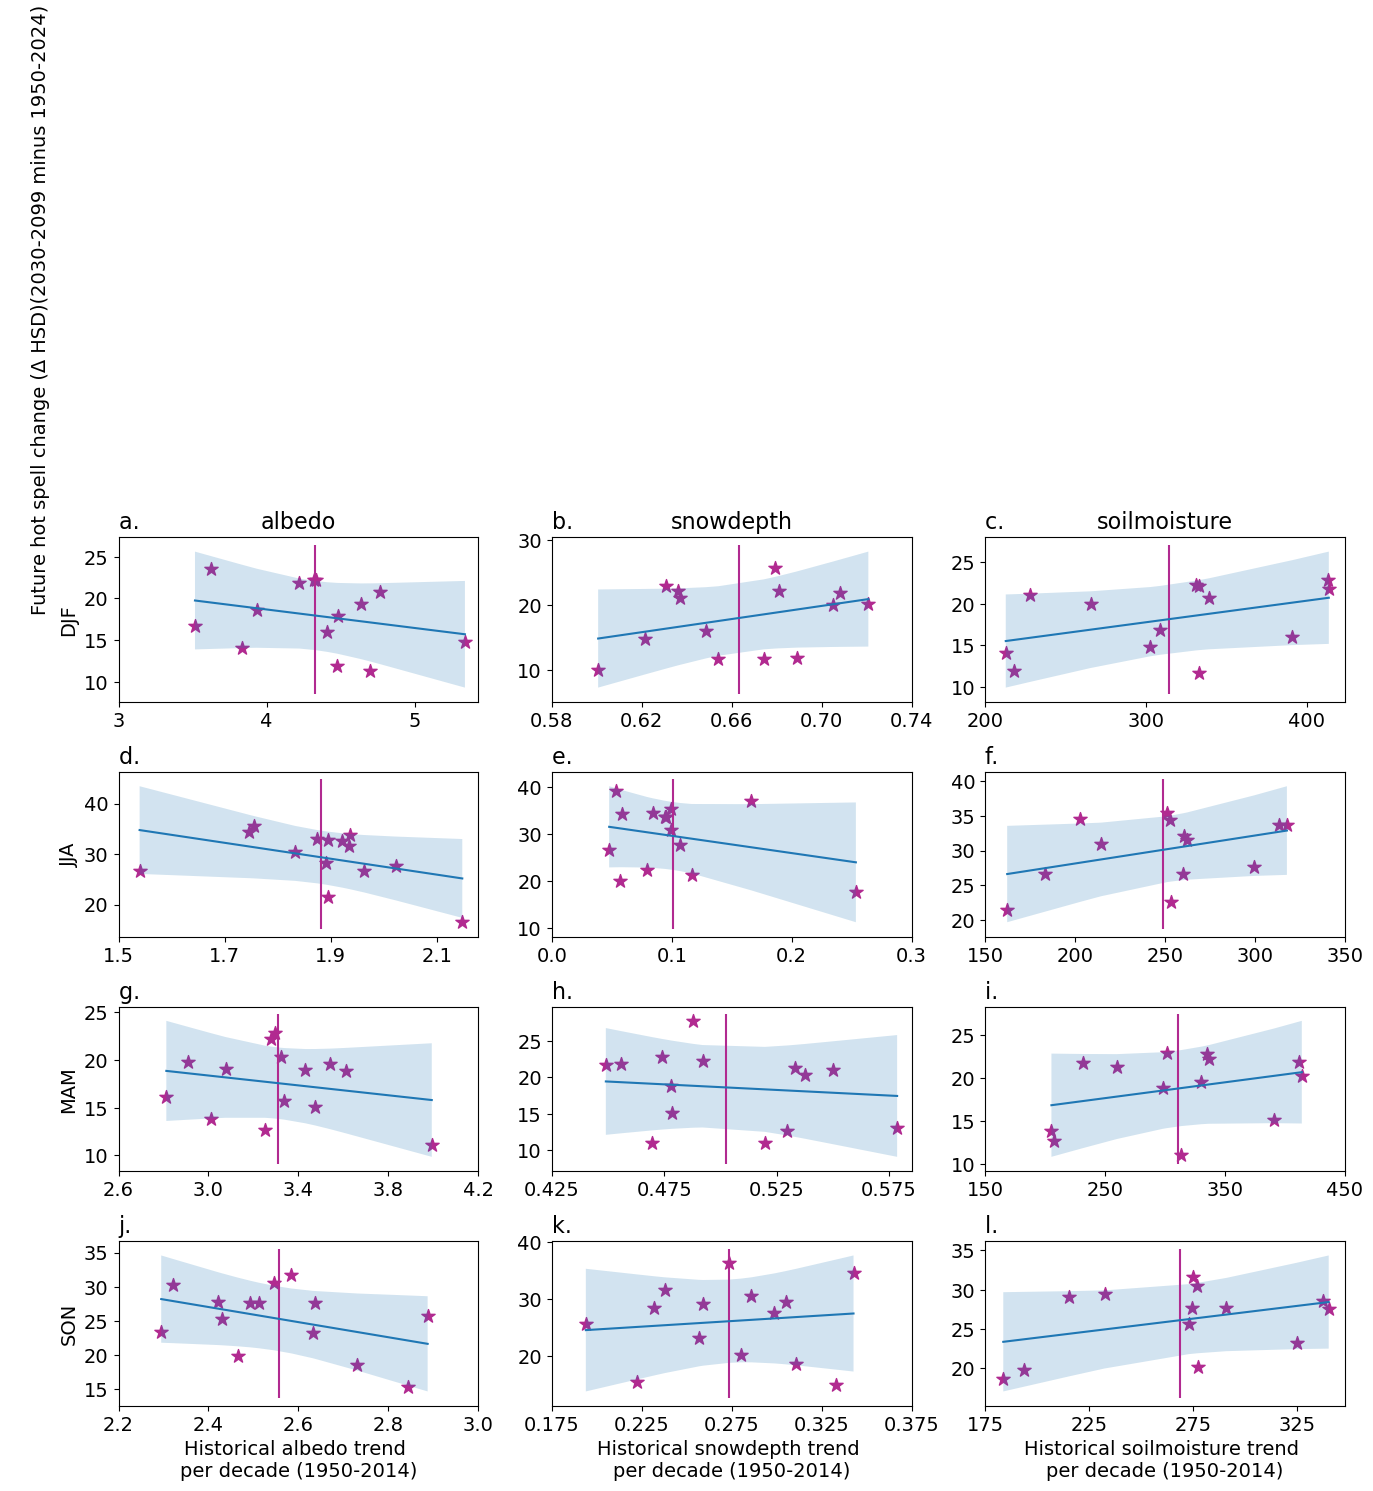

In [79]:
#plot correlation on average
fig=plt.figure(figsize=(14,10))
cmap = plt.get_cmap('plasma')
cmap2 = plt.get_cmap('YlGn')

fig.text(-2.82, 2.8, 'Future hot spell change (\u0394 HSD)(2030-2099 minus 1950-2024)', fontsize=14, rotation='vertical', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)


for i,season in enumerate(change_heatfut.season.values):
    for j,d in enumerate(dsta):
        num=(3*(i+1)+(j+1) -3)
        ax=fig.add_subplot(4,3,num)
        x_weighted=seas(d,season).sel(models=mnames1[j])
        y_weighted=seas(change_heatfut,season).sel(models=mnames1[j]).sortby(x_weighted.models)

#         xera_weighted=seas(trseas_tmp_era,season)
#         xbk_weighted=seas(trseas_tmp_bk,season)
        ax.scatter(10*x_weighted,y_weighted,marker='*', s=100,c=cmap(0.4),label='CMIP6 (μ)')

        #ax.vlines(10*xbk_weighted,0,10*y_weighted.max(),color=cmap2(0.75),linestyle='--',label='Berkeley (μ)')

        x_weighted2=x_weighted.sortby(x_weighted)
        y_weighted2=y_weighted.sortby(x_weighted)

        x=10*x_weighted2.values
        y=y_weighted2.values

        #xob=10*xera_weighted
        n=len(x)
        a, b = np.polyfit(x, y, deg=1)
        y_est = a * x + b



        y_mmm=y_est.mean()
        x_mmm=x.mean()

        #y_ob=a*(xob - x_mmm)+ y_mmm


        # Calculate the standard error of the estimate (manual formula)

        SE = np.sqrt((np.array(y)-y_est).var() * np.sqrt(1/len(x) + (x - x.mean())**2 / np.sum((x - x.mean())**2)))

        tc = t.ppf(0.975, n-2)
        CIupper=y_est+(tc*SE)
        CIlower=y_est-(tc*SE)


        ax.fill_between(x, CIlower, CIupper, alpha=0.2)


        #ax.fill_between(x, CIlowerob, CIupperob,color= 'red', alpha=0.2)

        ax.plot(x, y_est, '-', label='Linear Fit')

        ymin, ymax = plt.ylim()
        ax.vlines(10*x_weighted.mean(),ymin,ymax,color=cmap(0.4),label='CMIP6 mmm (μ)')
        #ax.vlines(10*xera_weighted,ymin,ymax,color='k', linestyle='-.',label='ERA5 (μ)')

        #ax.hlines(y_ob,x.min(),x.max(),color='red',linestyle='--',label='CMIP adjmean')

        #ax.fill_between(x, y_est - y_err, y_est + y_err, alpha=0.2, label='Uncertainty Band')
        ax.set_title(letters[num-1], loc='left', fontsize=16)
        ticks = ax.get_xticks()
        ax.set_xticks(ticks[::2])
        if i==0:
            ax.set_title(states[j], fontsize=16)
        ax.set_ylabel(season, fontsize=14)
        #ax.set_ylabel('Future hot spell change (\u0394 HSD) \n(2030-2099 minus 1950-2024)', fontsize=14)
        ax.set_xlabel('Historical '+states[j]+' trend \nper decade (1950-2014)', fontsize=14)

        if j%4>0:
            ax.set_ylabel('')
        if i<3:
            ax.set_xlabel('')


        plt.yticks(fontsize=14)
        plt.xticks(fontsize=14)
#     handles=[]
#     labels=[]
#     h, l = ax.get_legend_handles_labels()
#     handles.extend(h)
#     labels.extend(l)
    #fig.legend(handles, labels, loc='lower right', fontsize=14, bbox_to_anchor=(0.65, 0.1)) 
plt.tight_layout()
plt.subplots_adjust(left=0.1)
#fig.supylabel('Future hot spell change (\u0394 HSD) \n(2030-2099 minus 1950-2024)', fontsize=14)
plt.savefig('ECs_states2014-clim.png')


In [31]:
#Compute correlation values (against Future 30year)
#change_heat=htfut_lndclim.sel(year=slice(2070,2100)).mean(dim='year') - htfut_lndclim.sel(year=slice(1950,1980)).mean(dim='year') 

from scipy import stats
print ('Future')
for j,d in enumerate(dsta):
    for i,season in enumerate(change_heatfut.season.values):
#         num=(4*(i+1)+(j+1) -4)
#         ax=fig.add_subplot(4,4,num)
        x_weighted=seas(d,season).sel(models=mnames1[j])
        y_weighted=seas(change_heatfut,season).sel(models=mnames1[j]).sortby(x_weighted.models)
    
        res = stats.pearsonr(x_weighted,y_weighted)
        #if res[-1]<0.1 or res[0]>0.3:
        print(states[j],season+' Corr:',res)


Future
albedo DJF Corr: PearsonRResult(statistic=-0.2650842658170928, pvalue=0.35970953079759166)
albedo JJA Corr: PearsonRResult(statistic=-0.4349933462287521, pvalue=0.12007770596042507)
albedo MAM Corr: PearsonRResult(statistic=-0.22603172656139403, pvalue=0.4371465643175596)
albedo SON Corr: PearsonRResult(statistic=-0.4134157131590268, pvalue=0.14174365401863967)
snowdepth DJF Corr: PearsonRResult(statistic=0.30474792137914264, pvalue=0.289409742614099)
snowdepth JJA Corr: PearsonRResult(statistic=-0.34244098796928774, pvalue=0.230722092112981)
snowdepth MAM Corr: PearsonRResult(statistic=-0.28735191509717817, pvalue=0.31917755324748087)
snowdepth SON Corr: PearsonRResult(statistic=0.010138495372918594, pvalue=0.9725594774001816)
soilmoisture DJF Corr: PearsonRResult(statistic=0.4404401465390625, pvalue=0.1319960836924604)
soilmoisture JJA Corr: PearsonRResult(statistic=0.4304718725641998, pvalue=0.14200775972104668)
soilmoisture MAM Corr: PearsonRResult(statistic=0.32877728628106

In [30]:
#Compute correlation values (against historical 30year)
#change_heat=htfut_lndclim.sel(year=slice(1984,2014)).mean(dim='year') - htfut_lndclim.sel(year=slice(1950,1980)).mean(dim='year') 

from scipy import stats
print ('Historical')
for j,d in enumerate(dsta):
    for i,season in enumerate(change_heathist.season.values):
#         num=(4*(i+1)+(j+1) -4)
#         ax=fig.add_subplot(4,4,num)
        x_weighted=seas(d,season).sel(models=mnames1[j])
        y_weighted=seas(change_heathist,season).sel(models=mnames1[j]).sortby(x_weighted.models)
    
        res = stats.pearsonr(x_weighted,y_weighted)
        #if res[-1]<0.1 or res[0]>0.3:
        print(states[j],season+' Corr:',res)


Historical
albedo DJF Corr: PearsonRResult(statistic=-0.06141754254929087, pvalue=0.8347813223476248)
albedo JJA Corr: PearsonRResult(statistic=-0.13466891616862087, pvalue=0.6462293631075504)
albedo MAM Corr: PearsonRResult(statistic=0.016057977045750845, pvalue=0.9565492301650569)
albedo SON Corr: PearsonRResult(statistic=-0.2106680809847158, pvalue=0.46972143923340925)
snowdepth DJF Corr: PearsonRResult(statistic=0.37176685674585175, pvalue=0.1905852009126168)
snowdepth JJA Corr: PearsonRResult(statistic=0.011715475761552827, pvalue=0.9682930945493637)
snowdepth MAM Corr: PearsonRResult(statistic=0.16459259471286444, pvalue=0.5739186778693219)
snowdepth SON Corr: PearsonRResult(statistic=0.22716034031249233, pvalue=0.43479921229288643)
soilmoisture DJF Corr: PearsonRResult(statistic=0.5324690921133811, pvalue=0.06102334530901093)
soilmoisture JJA Corr: PearsonRResult(statistic=0.2761255304867662, pvalue=0.3611351290554138)
soilmoisture MAM Corr: PearsonRResult(statistic=0.1978278495